In [4]:
# import libraries
import pandas as pd
import numpy as np

In [8]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [13]:
# pd.read_csv()
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])
# dropna()
df.dropna(inplace=True)
df.shape

(714, 3)

In [14]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [16]:
X = df.iloc[:,1:3] # inculde all columns except survived
y = df.iloc[:,0]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42
)

In [20]:
# Check for the shape of train and test.
X_train.shape, X_test.shape

((571, 2), (143, 2))

In [21]:
# Create Object of 'DecisionTreeClassifier'
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [22]:
# Get the predict values for the X_test
y_pred = clf.predict(X_test)

# Check for the accuracy_score
accuracy_score(y_test, y_pred)

0.6293706293706294

In [23]:
# cross_val_score
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring = 'accuracy'))

np.float64(0.6275234741784036)

In [33]:
kbin_age = KBinsDiscretizer(n_bins=19, encode='ordinal', strategy='kmeans')
kbin_fare = KBinsDiscretizer(n_bins=19, encode='ordinal', strategy='kmeans')

In [34]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second', kbin_fare, [1])
])

In [35]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.fit_transform(X_test)

In [36]:
# transformers data for first column, similar for second.
trf.named_transformers_['first'].bin_edges_

array([array([ 1.        ,  4.33333333,  7.5       , 10.        , 13.63461538,
              17.82692308, 20.51048951, 23.33484848, 26.65952381, 29.85119048,
              33.16987179, 36.31868132, 39.10714286, 42.32142857, 45.82142857,
              49.25      , 52.5       , 55.5       , 59.33333333, 62.        ])],
      dtype=object)

In [37]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf': X_train_trf[:,0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:,1]
})

In [39]:
output['age_labels'] = pd.cut(
    x=X_train['Age'],
    bins = trf.named_transformers_['first'].bin_edges_[0].tolist())

output['fare_labels'] = pd.cut(
    x=X_train['Fare'],
    bins = trf.named_transformers_['second'].bin_edges_[0].tolist())

In [40]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
70,32.0,7.0,10.500,1.0,"(29.851, 33.17]","(5.689, 10.846]"
841,16.0,3.0,10.500,1.0,"(13.635, 17.827]","(5.689, 10.846]"
222,51.0,12.0,8.050,1.0,"(49.25, 52.5]","(5.689, 10.846]"
661,40.0,9.0,7.225,1.0,"(39.107, 42.321]","(5.689, 10.846]"
113,20.0,4.0,9.825,1.0,"(17.827, 20.51]","(5.689, 10.846]"


In [43]:
# Create Object of 'DecisionTreeclassifier'
clf = DecisionTreeClassifier()
clf.fit(X_train_trf, y_train)

# predict the values
y_pred2 = clf.predict(X_test_trf)

# Get the accuracy score
accuracy_score(y_test, y_pred2)

0.6013986013986014

In [47]:
# Define a function Discretizer

def discretizer(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=19, encode='ordinal', strategy='kmeans')
    kbin_fare = KBinsDiscretizer(n_bins=19, encode='ordinal', strategy='kmeans')

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),
        ('second', kbin_fare, [1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv=10, scoring='accuracy')))

    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:, 0], color='red')
    plt.title("After")

    # show graph
    plt.show()

0.6289123630672926


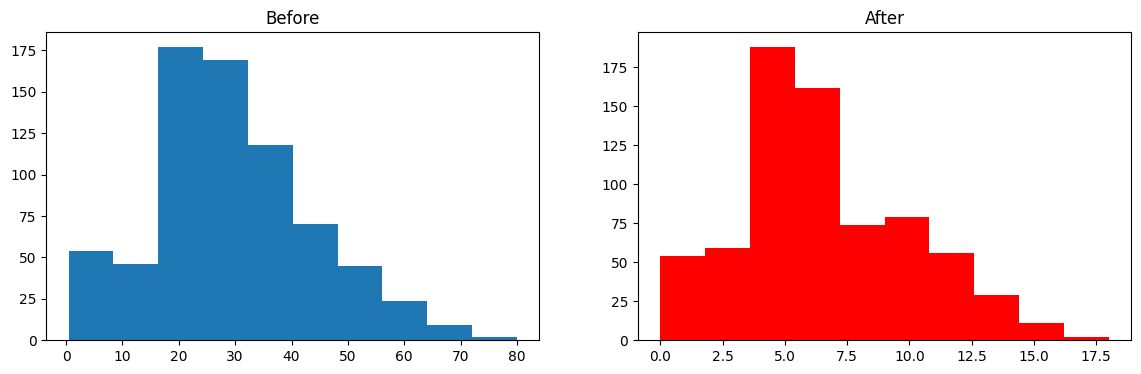

In [49]:
# Let's call the function
discretizer(10, 'kmeans')

## *Binarization*

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
885,0,39.0,29.1250
886,0,27.0,13.0000
887,1,19.0,30.0000
889,1,26.0,30.0000


In [51]:
# pd.read_csv()
df = pd.read_csv('train.csv', usecols=['Age','Fare','SibSp', 'Parch','Survived'])
# dropna()
df.dropna(inplace=True)
df.shape

(714, 5)

In [52]:
df.head()

,Survived,Age,SibSp,Parch,Fare
0,0,22.0,1,0,7.2500
1,1,38.0,1,0,71.2833
2,1,26.0,0,0,7.9250
3,1,35.0,1,0,53.1000
4,0,35.0,0,0,8.0500


In [54]:
df['family'] = df['SibSp'] + df['Parch']

In [57]:
df.head() # Get the top-5 rows 
df.drop(columns=['SibSp', 'Parch'], inplace=True)

In [58]:
df.head()

,Survived,Age,Fare,family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [59]:
# Dependent and Independent columns
X = df.drop(columns=['Survived'])
y = df['Survived']

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [61]:
X_train.head()

,Age,Fare,family
328,31.0,20.5250,2
73,26.0,14.4542,1
253,30.0,16.1000,1
719,33.0,7.7750,0
666,25.0,13.0000,0


In [62]:
# Create Object of DecisionTreeClassifier
clf = DecisionTreeClassifier()

# fit the model
clf.fit(X_train, y_train)

# get y_pred
y_pred1 = clf.predict(X_test)

# accuracy_score
accuracy_score(y_test, y_pred1)

0.6153846153846154

In [64]:
# cross_val_score
np.mean(cross_val_score(DecisionTreeClassifier(), X, y, cv= 10, scoring='accuracy'))

np.float64(0.6485328638497652)

In [68]:
# Apply binarization
from sklearn.preprocessing import Binarizer

In [69]:
trf = ColumnTransformer([
    ('bin', Binarizer(copy=False), ['family'])
], remainder='passthrough')

In [70]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.fit_transform(X_test)

In [72]:
pd.DataFrame(X_train_trf, columns=['family', 'Age', 'Fare']).head()

,family,Age,Fare
0,1.0,31.0,20.5250
1,1.0,26.0,14.4542
2,1.0,30.0,16.1000
3,0.0,33.0,7.7750
4,0.0,25.0,13.0000


In [73]:
# with transformer
# Create Object of DecisionTreeClassifier
clf = DecisionTreeClassifier()

# fit the model
clf.fit(X_train_trf, y_train)

# get y_pred
y_pred2 = clf.predict(X_test_trf)

# accuracy_score
accuracy_score(y_test, y_pred2)

0.6153846153846154